<a href="https://colab.research.google.com/github/Kseniaa31/Data-Science/blob/Stock-Prices/Stock_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA COLLECTION**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
df=pd.read_csv("BAJAJFINSV.csv")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2008-05-26,BAJAJFINSV,EQ,2101.05,600.00,619.00,501.0,505.1,509.10,548.85,3145446,1.726368e+14,NaN,908264,0.2888
1,2008-05-27,BAJAJFINSV,EQ,509.10,505.00,610.95,491.1,564.0,554.65,572.15,4349144,2.488370e+14,NaN,677627,0.1558
2,2008-05-28,BAJAJFINSV,EQ,554.65,564.00,665.60,564.0,643.0,640.95,618.37,4588759,2.837530e+14,NaN,774895,0.1689
3,2008-05-29,BAJAJFINSV,EQ,640.95,656.65,703.00,608.0,634.5,632.40,659.60,4522302,2.982921e+14,NaN,1006161,0.2225
4,2008-05-30,BAJAJFINSV,EQ,632.40,642.40,668.00,588.3,647.0,644.00,636.41,3057669,1.945929e+14,NaN,462832,0.1514


In [3]:
data=df.set_index("Date")
data.head()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,
2008-05-26,BAJAJFINSV,EQ,2101.05,600.00,619.00,501.0,505.1,509.10,548.85,3145446,1.726368e+14,NaN,908264,0.2888
2008-05-27,BAJAJFINSV,EQ,509.10,505.00,610.95,491.1,564.0,554.65,572.15,4349144,2.488370e+14,NaN,677627,0.1558
2008-05-28,BAJAJFINSV,EQ,554.65,564.00,665.60,564.0,643.0,640.95,618.37,4588759,2.837530e+14,NaN,774895,0.1689
2008-05-29,BAJAJFINSV,EQ,640.95,656.65,703.00,608.0,634.5,632.40,659.60,4522302,2.982921e+14,NaN,1006161,0.2225
2008-05-30,BAJAJFINSV,EQ,632.40,642.40,668.00,588.3,647.0,644.00,636.41,3057669,1.945929e+14,NaN,462832,0.1514


In [4]:
data.describe()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,3201.000000,3201.000000,3201.000000,3201.000000,3201.000000,3201.000000,3201.000000,3.201000e+03,3.201000e+03,2456.000000,3.201000e+03,3201.000000
mean,2755.864386,2760.382381,2803.614449,2716.731443,2758.781537,2758.657451,2761.156954,2.315312e+05,9.533424e+13,20892.811075,7.409510e+04,0.471614
std,2869.811765,2874.814173,2912.885262,2834.037357,2873.792614,2873.522615,2874.033545,4.402681e+05,2.176448e+14,32396.302068,1.464012e+05,0.218910
min,90.750000,88.150000,93.100000,88.150000,91.000000,90.750000,89.260000,4.570000e+02,1.376712e+10,149.000000,4.560000e+02,0.056200
25%,527.900000,528.600000,542.600000,520.000000,527.950000,527.900000,531.270000,3.981100e+04,2.751053e+12,2951.750000,2.086300e+04,0.287400
50%,1098.700000,1095.000000,1118.000000,1080.250000,1100.000000,1098.700000,1103.560000,9.995300e+04,1.090486e+13,9450.000000,4.159700e+04,0.469700
75%,5121.900000,5120.000000,5199.800000,5042.800000,5115.000000,5125.100000,5127.510000,2.315400e+05,8.755946e+13,24439.750000,8.308900e+04,0.636000
max,11176.550000,11000.000000,11300.000000,10868.700000,11175.450000,11176.550000,11081.780000,6.271671e+06,3.394379e+15,312959.000000,3.804696e+06,1.000000


# **DATA PREPROCESSING**

In [5]:
data[data['Trades'].isna()]
dataframe = data.drop(columns=["Trades"], axis=1)
dataframe.columns

Index(['Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Deliverable Volume',
       '%Deliverble'],
      dtype='object')

In [6]:
data[dataframe.duplicated()]

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,


In [7]:
dataframe.dtypes

,0
Symbol,object
Series,object
Prev Close,float64
Open,float64
High,float64
Low,float64
Last,float64
Close,float64
VWAP,float64
Volume,int64


# **DATA ANALYSIS**

<Axes: xlabel='Date'>

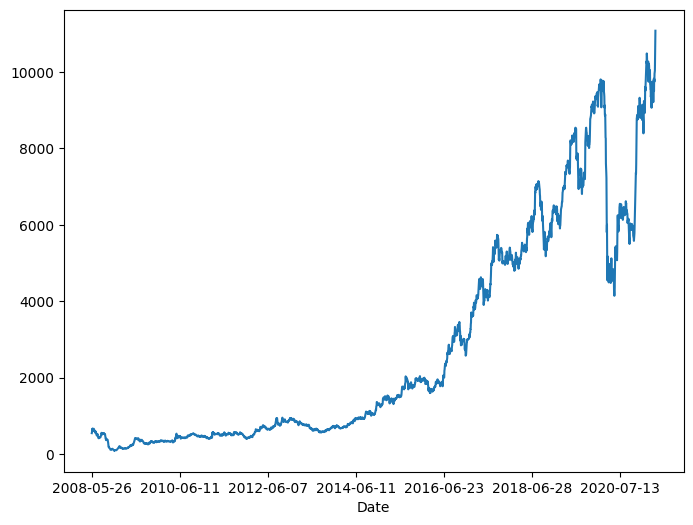

In [8]:
data['VWAP'].plot(figsize = (8,6))
#decline in 2020 due to the impact of Covid19

<Axes: xlabel='VWAP', ylabel='Count'>

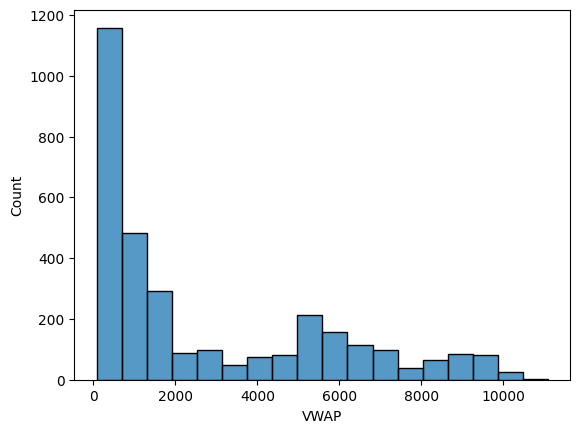

In [9]:
sns.histplot(data = dataframe, x="VWAP")

<Axes: xlabel='VWAP', ylabel='Density'>

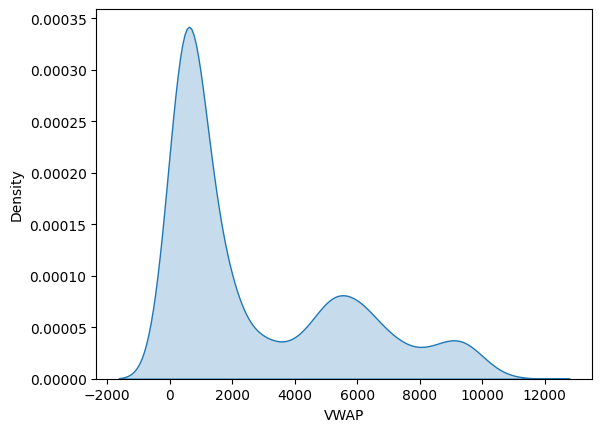

In [10]:
sns.kdeplot(data= dataframe, x="VWAP", fill=True) #distribution/density plot

((array([-3.51908695, -3.27647555, -3.14237236, ...,  3.14237236,
          3.27647555,  3.51908695]),
  array([   89.26,    93.99,    94.79, ..., 10486.75, 10980.4 , 11081.78])),
 (2583.530410402808, 2761.156954076851, 0.8981685068494002))

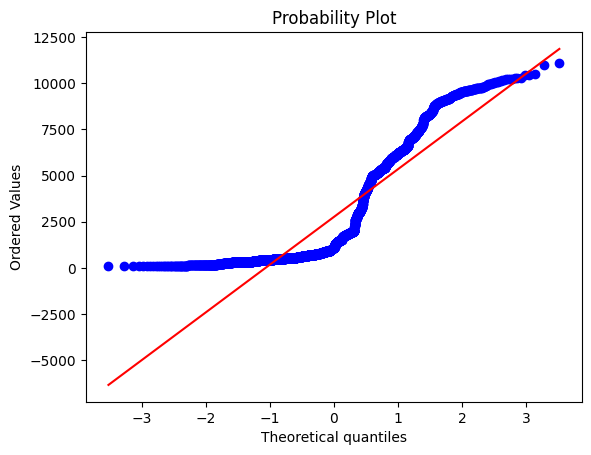

In [11]:
from scipy import stats
stats.probplot(x = dataframe["VWAP"], plot=plt)

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

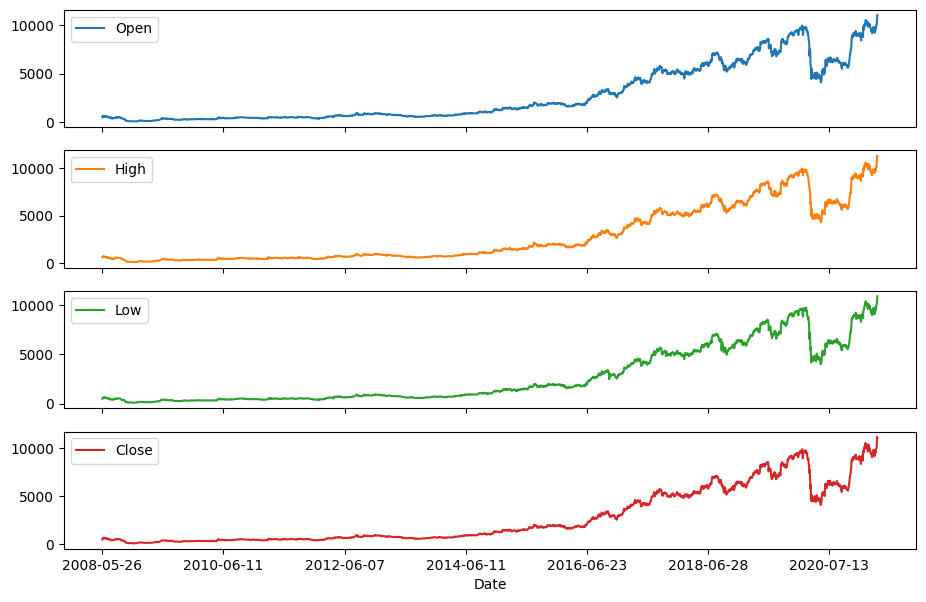

In [12]:
cols= ['Open', 'High', 'Low', 'Close']
dataframe[cols].plot(figsize=(11,7),subplots= True)

In [13]:
!pip install plotly
import plotly.graph_objects as go

In [14]:
go.Figure(data= [go.Candlestick(x=dataframe.index[0:50],
                                open = dataframe['Open'][0:50],
                                high = dataframe['High'][0:50],
                                low = dataframe['Low'][0:50],
                                close = dataframe['Close'][0:50],
                                )])
#Candlestick graph

# **FEATURE ENGINEERING**

In [15]:
lag_features=['High', 'Low', 'Volume', 'Turnover']
window1=3
window2=7

In [16]:
for col in lag_features:
  dataframe[col+"_rolling_mean_3"] = dataframe[col].rolling(window=window1).mean()
  dataframe[col+"_rolling_mean_7"] = dataframe[col].rolling(window=window2).mean()
dataframe.head()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,Deliverable Volume,%Deliverble,High_rolling_mean_3,High_rolling_mean_7,Low_rolling_mean_3,Low_rolling_mean_7,Volume_rolling_mean_3,Volume_rolling_mean_7,Turnover_rolling_mean_3,Turnover_rolling_mean_7
Date,,,,,,,,,,,,,,,,,,,,,
2008-05-26,BAJAJFINSV,EQ,2101.05,600.00,619.00,501.0,505.1,509.10,548.85,3145446,...,908264,0.2888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-05-27,BAJAJFINSV,EQ,509.10,505.00,610.95,491.1,564.0,554.65,572.15,4349144,...,677627,0.1558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-05-28,BAJAJFINSV,EQ,554.65,564.00,665.60,564.0,643.0,640.95,618.37,4588759,...,774895,0.1689,631.850000,NaN,518.700000,NaN,4.027783e+06,NaN,2.350756e+14,NaN
2008-05-29,BAJAJFINSV,EQ,640.95,656.65,703.00,608.0,634.5,632.40,659.60,4522302,...,1006161,0.2225,659.850000,NaN,554.366667,NaN,4.486735e+06,NaN,2.769607e+14,NaN
2008-05-30,BAJAJFINSV,EQ,632.40,642.40,668.00,588.3,647.0,644.00,636.41,3057669,...,462832,0.1514,678.866667,NaN,586.766667,NaN,4.056243e+06,NaN,2.588793e+14,NaN


In [17]:
for col in lag_features:
  dataframe[col+"_rolling_std_3"] = dataframe[col].rolling(window=window1).std()
  dataframe[col+"_rolling_std_7"] = dataframe[col].rolling(window=window2).std()
dataframe.head()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,Turnover_rolling_mean_3,Turnover_rolling_mean_7,High_rolling_std_3,High_rolling_std_7,Low_rolling_std_3,Low_rolling_std_7,Volume_rolling_std_3,Volume_rolling_std_7,Turnover_rolling_std_3,Turnover_rolling_std_7
Date,,,,,,,,,,,,,,,,,,,,,
2008-05-26,BAJAJFINSV,EQ,2101.05,600.00,619.00,501.0,505.1,509.10,548.85,3145446,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-05-27,BAJAJFINSV,EQ,509.10,505.00,610.95,491.1,564.0,554.65,572.15,4349144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-05-28,BAJAJFINSV,EQ,554.65,564.00,665.60,564.0,643.0,640.95,618.37,4588759,...,2.350756e+14,NaN,29.504195,NaN,39.542003,NaN,773461.552524,NaN,5.682195e+13,NaN
2008-05-29,BAJAJFINSV,EQ,640.95,656.65,703.00,608.0,634.5,632.40,659.60,4522302,...,2.769607e+14,NaN,46.293601,NaN,59.042386,NaN,123703.660710,NaN,2.541759e+13,NaN
2008-05-30,BAJAJFINSV,EQ,632.40,642.40,668.00,588.3,647.0,644.00,636.41,3057669,...,2.588793e+14,NaN,20.934501,NaN,22.040039,NaN,865428.886510,NaN,5.614629e+13,NaN


# **MODEL BUILDING**

In [21]:
dataframe.dropna(inplace=True)
training_data=dataframe[0:2400]
testing_data=dataframe[2400:]

In [36]:
import pmdarima
from pmdarima import auto_arima

In [27]:
dataframe.columns

Index(['Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Deliverable Volume',
       '%Deliverble', 'High_rolling_mean_3', 'High_rolling_mean_7',
       'Low_rolling_mean_3', 'Low_rolling_mean_7', 'Volume_rolling_mean_3',
       'Volume_rolling_mean_7', 'Turnover_rolling_mean_3',
       'Turnover_rolling_mean_7', 'High_rolling_std_3', 'High_rolling_std_7',
       'Low_rolling_std_3', 'Low_rolling_std_7', 'Volume_rolling_std_3',
       'Volume_rolling_std_7', 'Turnover_rolling_std_3',
       'Turnover_rolling_std_7'],
      dtype='object')

In [30]:
ind_features=['High_rolling_mean_3', 'High_rolling_mean_7',
       'Low_rolling_mean_3', 'Low_rolling_mean_7', 'Volume_rolling_mean_3',
       'Volume_rolling_mean_7', 'Turnover_rolling_mean_3',
       'Turnover_rolling_mean_7', 'High_rolling_std_3', 'High_rolling_std_7',
       'Low_rolling_std_3', 'Low_rolling_std_7', 'Volume_rolling_std_3',
       'Volume_rolling_std_7', 'Turnover_rolling_std_3',
       'Turnover_rolling_std_7']

model = auto_arima(y = training_data['VWAP'], X = training_data[ind_features], trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=21501.827, Time=10.11 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=22553.316, Time=4.85 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=21962.078, Time=4.24 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=21621.883, Time=11.96 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=38832.057, Time=3.76 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=21603.202, Time=10.49 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=21569.178, Time=9.88 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=21504.409, Time=13.30 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=21496.739, Time=13.09 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=21507.705, Time=12.77 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=21498.526, Time=13.06 sec
 ARIMA(2,0,4)(0,0,0)[0] intercept   : AIC=21493.512, Time=14.22 sec
 ARIMA(1,0,4)(0,0,0)[0] intercept   : AIC=21504.632, Time=13.98 sec
 ARIMA(3,0,4)(0,0,0)[0] intercept   : AIC=21484.767, Time=13.71 sec
 ARIMA(4,

In [31]:
model

ARIMA(order=(3, 0, 4), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [32]:
forecast = model.predict(n_periods = len(testing_data), X= testing_data[ind_features])
forecast

,0
2400,5062.232272
2401,5067.142982
2402,5140.062416
2403,5181.648066
2404,5206.023326
...,...
3190,9986.660883
3191,10045.074683
3192,10286.940502
3193,10784.834286


<Axes: xlabel='Date'>

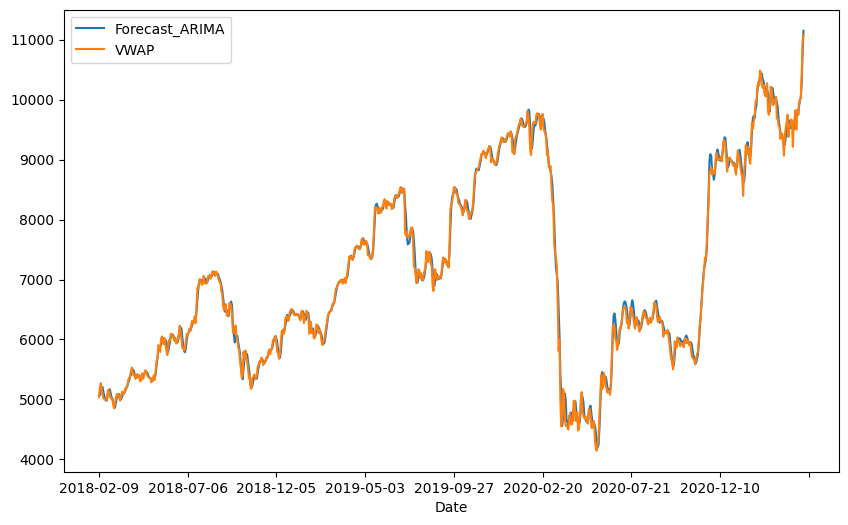

In [33]:
testing_data["Forecast_ARIMA"] = forecast.values
testing_data[["Forecast_ARIMA", "VWAP"]].plot(figsize=(10,6))

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print(mean_squared_error(testing_data["VWAP"], testing_data["Forecast_ARIMA"]))
print(np.sqrt(mean_squared_error(testing_data["VWAP"], testing_data["Forecast_ARIMA"])))
print(mean_absolute_error(testing_data["VWAP"], testing_data["Forecast_ARIMA"]))

11857.648902780127
108.89283219193138
76.36075997041975
